In [1]:
!pip install pandas_datareader matplotlib

In [2]:
fred_api_key = 'e2e26383c4111b0b1549557ee4608399'

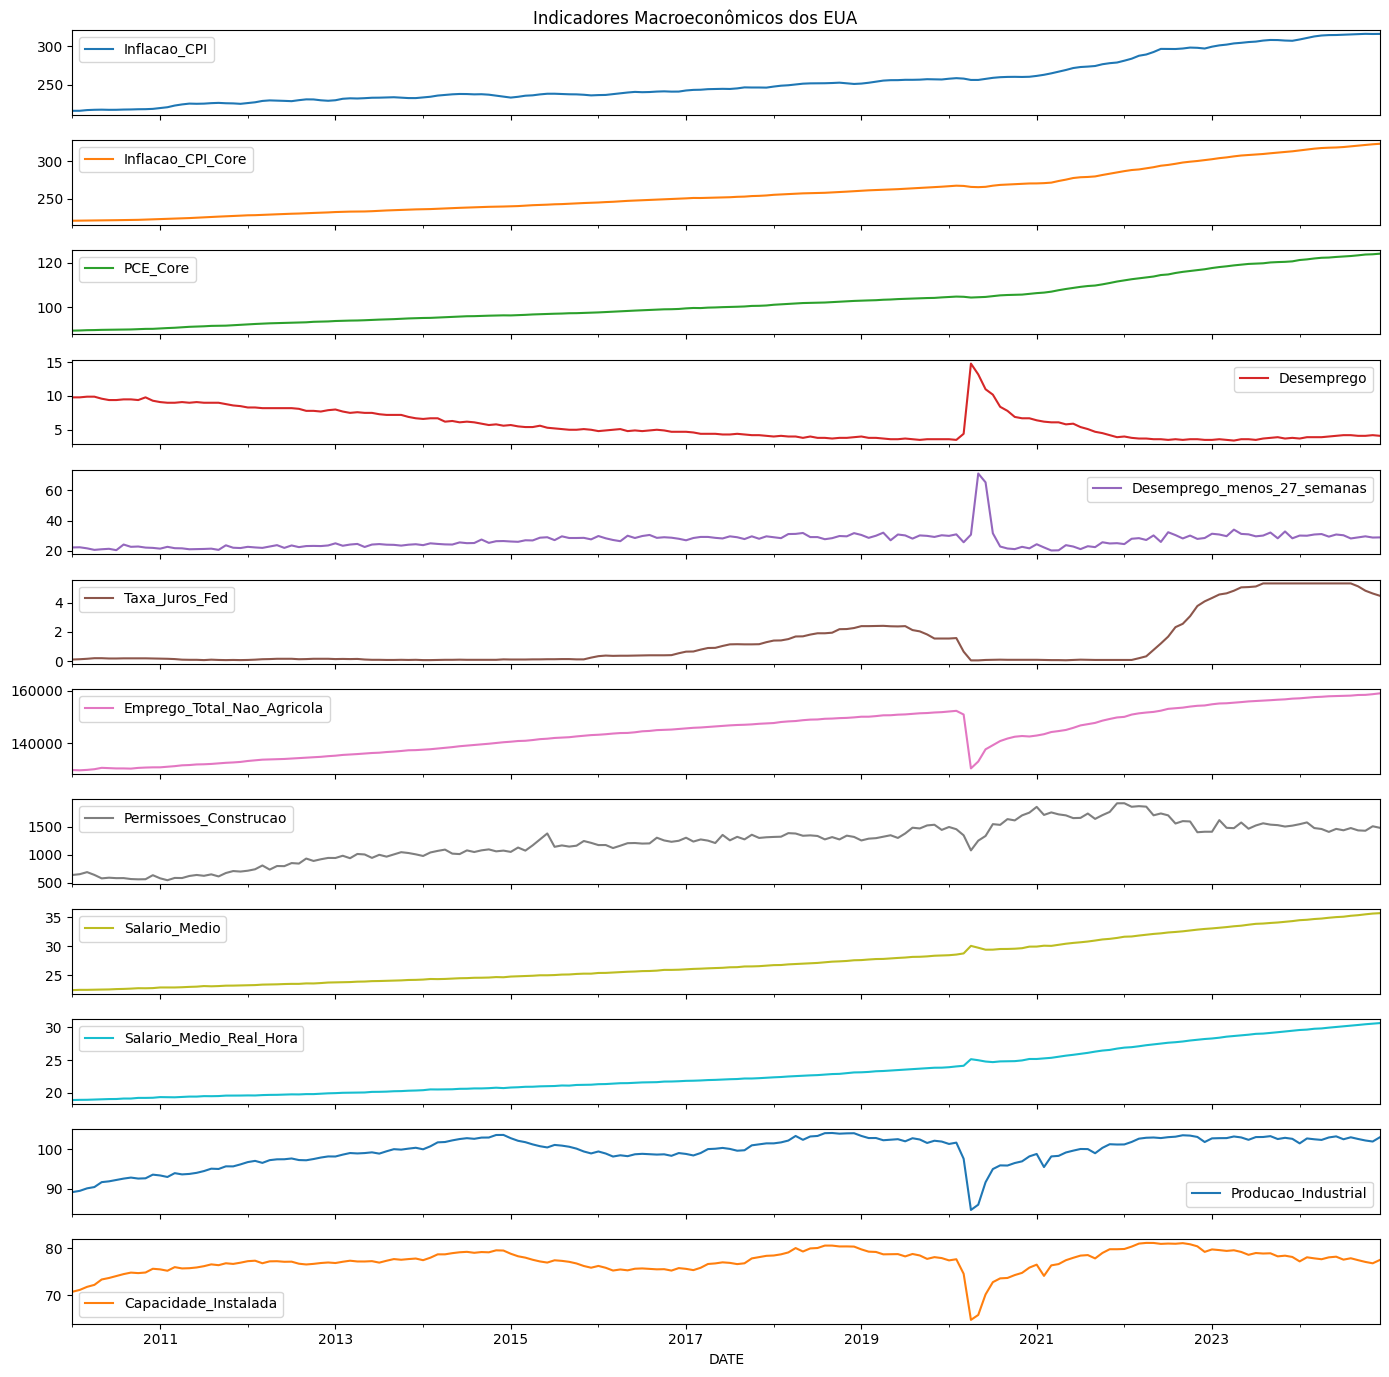

In [16]:
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime



# === Datas do período desejado ===
start_date = datetime(2010, 1, 1)
end_date = datetime(2024, 12, 31)

# === Dicionário com os indicadores e códigos do FRED ===
series = {
    'Inflacao_CPI': 'CPIAUCNS',  # Substituído CUUR0000SA0 por CPIAUCNS (mesma base, mensal)
    'Inflacao_CPI_Core': 'CPILFESL',
    'PCE_Core': 'PCEPILFE',
    'Desemprego': 'UNRATE',
    'Desemprego_menos_27_semanas': 'LNS13025701',  # Alternativa para desemprego < 27 semanas
    'Taxa_Juros_Fed': 'FEDFUNDS',
    'Emprego_Total_Nao_Agricola': 'PAYEMS',
    'Permissoes_Construcao': 'PERMIT',
    'Salario_Medio': 'CES0500000003',
    'Salario_Medio_Real_Hora': 'AHETPI',
    'Producao_Industrial': 'INDPRO',
    'Capacidade_Instalada': 'TCU'
}

# === Coleta os dados ===
df = pd.DataFrame()
for nome, codigo in series.items():
    try:
        df[nome] = web.DataReader(codigo, 'fred', start_date, end_date, api_key=fred_api_key)
    except Exception as e:
        print(f'Erro ao coletar {nome} ({codigo}): {e}')

# === Visualização simples ===
df.plot(subplots=True, figsize=(14, 14), title='Indicadores Macroeconômicos dos EUA')
plt.tight_layout()
plt.show()

df.reset_index(inplace=True)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   DATE                         180 non-null    datetime64[ns]
 1   Inflacao_CPI                 180 non-null    float64       
 2   Inflacao_CPI_Core            180 non-null    float64       
 3   PCE_Core                     180 non-null    float64       
 4   Desemprego                   180 non-null    float64       
 5   Desemprego_menos_27_semanas  180 non-null    float64       
 6   Taxa_Juros_Fed               180 non-null    float64       
 7   Emprego_Total_Nao_Agricola   180 non-null    int64         
 8   Permissoes_Construcao        180 non-null    int64         
 9   Salario_Medio                180 non-null    float64       
 10  Salario_Medio_Real_Hora      180 non-null    float64       
 11  Producao_Industrial          180 non-null    

In [23]:
import pandas_datareader.data as web
import pandas as pd
from datetime import datetime

# Datas do período desejado
start_date = datetime(2010, 1, 1)
end_date = datetime(2024, 12, 31)

# Indicadores com frequência diária
daily_series = {
    'Indice_Dolar': 'DTWEXAFEGS',
    'TIPS_5_anos_nominal': 'DGS5',
    'TIPS_5_anos_infl_ajustado': 'DFII5'
}

# Coletar dados com a API do FRED
df_dados_diarios = pd.DataFrame()
for nome, codigo in daily_series.items():
    df_dados_diarios[nome] = web.DataReader(codigo, 'fred', start_date, end_date, api_key=fred_api_key)

# Extrair os primeiros valores disponíveis de cada mês
df_primeiro_dia_mes = df_dados_diarios.resample('MS').first().dropna(how='all')  # MS = Month Start

# Resetar o índice para visualização
df_primeiro_dia_mes.reset_index(inplace=True)

# Exibir os dados do primeiro dia de cada mês
print(df_primeiro_dia_mes.head(
))  # Exibe os 12 primeiros meses


        DATE  Indice_Dolar  TIPS_5_anos_nominal  TIPS_5_anos_infl_ajustado
0 2010-01-01       87.8890                 2.65                       0.52
1 2010-02-01       89.8344                 2.38                       0.39
2 2010-03-01       90.5404                 2.28                       0.45
3 2010-04-01       89.7470                 2.59                       0.74
4 2010-05-01       91.1109                 2.47                       0.47


In [24]:
df_primeiro_dia_mes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   DATE                       180 non-null    datetime64[ns]
 1   Indice_Dolar               180 non-null    float64       
 2   TIPS_5_anos_nominal        180 non-null    float64       
 3   TIPS_5_anos_infl_ajustado  180 non-null    float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 5.8 KB


In [33]:
import pandas_datareader.data as web
import pandas as pd
from datetime import datetime

# Datas do período desejado
start_date = datetime(2010, 1, 1)
end_date = datetime(2024, 12, 31)

# API key definida previamente
# fred_api_key = 'sua_api_key_aqui'

# Indicadores trimestrais
trimestrais = {
    'PCE': 'PCECTPI',
    'Deflator_PIB': 'GDPDEF',
    'PIB_Real': 'GDPC1',
    'PIB': 'GDP'
}

# Baixar dados trimestrais
df_trimestral = pd.DataFrame()
for nome, codigo in trimestrais.items():
    try:
        df_trimestral[nome] = web.DataReader(codigo, 'fred', start_date, end_date, api_key=fred_api_key)
    except Exception as e:
        print(f'Erro ao coletar {nome} ({codigo}): {e}')

# Resetar índice para coluna DATE
df_trimestral.reset_index(inplace=True)

# Criar índice mensal para todo o período
indice_mensal = pd.date_range(start=start_date, end=end_date, freq='MS')  # MS = mês início

# Definir a coluna DATE como índice
df_trimestral.set_index('DATE', inplace=True)

# Reindexar para índice mensal (adiciona meses faltantes com NaN)
df_trimestral_mensal = df_trimestral.reindex(indice_mensal)

# Preencher os meses faltantes replicando o valor trimestral (forward fill)
df_trimestral_mensal = df_trimestral_mensal.fillna(method='ffill')

# Resetar índice para visualizar
df_trimestral_mensal.reset_index(inplace=True)
df_trimestral_mensal.rename(columns={'index': 'DATE'}, inplace=True)

print(df_trimestral_mensal.head())


        DATE     PCE  Deflator_PIB   PIB_Real        PIB
0 2010-01-01  90.177        89.036  16582.710  14764.610
1 2010-02-01  90.177        89.036  16582.710  14764.610
2 2010-03-01  90.177        89.036  16582.710  14764.610
3 2010-04-01  90.317        89.471  16743.162  14980.193
4 2010-05-01  90.317        89.471  16743.162  14980.193


/tmp/ipython-input-33-1564816769.py:41: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_trimestral_mensal = df_trimestral_mensal.fillna(method='ffill')


In [35]:
df_trimestral_mensal.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 180 entries, 2010-01-01 to 2024-12-01
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PCE           180 non-null    float64
 1   Deflator_PIB  180 non-null    float64
 2   PIB_Real      180 non-null    float64
 3   PIB           180 non-null    float64
dtypes: float64(4)
memory usage: 7.0 KB


In [43]:
# Primeiro, garantir que as colunas DATE estejam no mesmo formato datetime e como coluna comum
for dataframe in [df, df_trimestral_mensal, df_primeiro_dia_mes]:
    dataframe['DATE'] = pd.to_datetime(dataframe['DATE'])

# Realizar merge entre df e df_trimestral_mensal pela coluna DATE
df_merged = pd.merge(df, df_trimestral_mensal, on='DATE', how='left', suffixes=('', '_trimestral'))

# Realizar merge entre df_merged e df_primeiro_dia_mes pela coluna DATE
df_merged = pd.merge(df_merged, df_primeiro_dia_mes, on='DATE', how='left', suffixes=('', '_primeiro_dia'))

# Conferir as primeiras linhas para verificar
print(df_merged.head())


        DATE  Inflacao_CPI  Inflacao_CPI_Core  PCE_Core  Desemprego  \
0 2010-01-01       216.687            220.633    89.368         9.8   
1 2010-02-01       216.741            220.731    89.446         9.8   
2 2010-03-01       217.631            220.783    89.579         9.9   
3 2010-04-01       218.009            220.822    89.625         9.9   
4 2010-05-01       218.178            220.962    89.724         9.6   

   Desemprego_menos_27_semanas  Taxa_Juros_Fed  Emprego_Total_Nao_Agricola  \
0                         22.3            0.11                      129802   
1                         22.4            0.13                      129705   
2                         21.7            0.16                      129865   
3                         20.7            0.20                      130120   
4                         21.1            0.20                      130643   

   Permissoes_Construcao  Salario_Medio  Salario_Medio_Real_Hora  \
0                    636          22

In [44]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   DATE                         180 non-null    datetime64[ns]
 1   Inflacao_CPI                 180 non-null    float64       
 2   Inflacao_CPI_Core            180 non-null    float64       
 3   PCE_Core                     180 non-null    float64       
 4   Desemprego                   180 non-null    float64       
 5   Desemprego_menos_27_semanas  180 non-null    float64       
 6   Taxa_Juros_Fed               180 non-null    float64       
 7   Emprego_Total_Nao_Agricola   180 non-null    int64         
 8   Permissoes_Construcao        180 non-null    int64         
 9   Salario_Medio                180 non-null    float64       
 10  Salario_Medio_Real_Hora      180 non-null    float64       
 11  Producao_Industrial          180 non-null    

In [45]:
# === Salvar em CSV ===
df_merged.to_csv('dados_macroeconomicos_usa.csv')
